In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
import pandas as pd

In [6]:
df = pd.read_csv("output/default.csv")
df.head()

,EventID,Momentum (MeV/c),Transverse Momentum (MeV/c),Z Momentum (MeV/c),Pseudorapidity,Momentum Accuracy (%),Transverse Momentum Accuracy (%),Z Momentum Accuracy (%),DCA (mm),RMSE
0,632,700,699.324386,30.747398,0.043953,0.319880,0.322406,200.977948,0.052198,0.018291
1,633,2000,1835.923621,-793.337544,-0.419689,0.323749,0.347568,200.196090,0.007194,0.010268
2,634,700,194.960790,-672.302231,-1.951447,0.755706,0.430691,200.782990,0.033023,0.123890
3,635,500,487.415367,-111.473138,-0.226754,0.209486,0.258188,200.717102,0.024048,0.017241
4,636,700,699.322923,-30.780676,-0.044001,0.022222,0.020288,198.974326,0.009012,0.023636


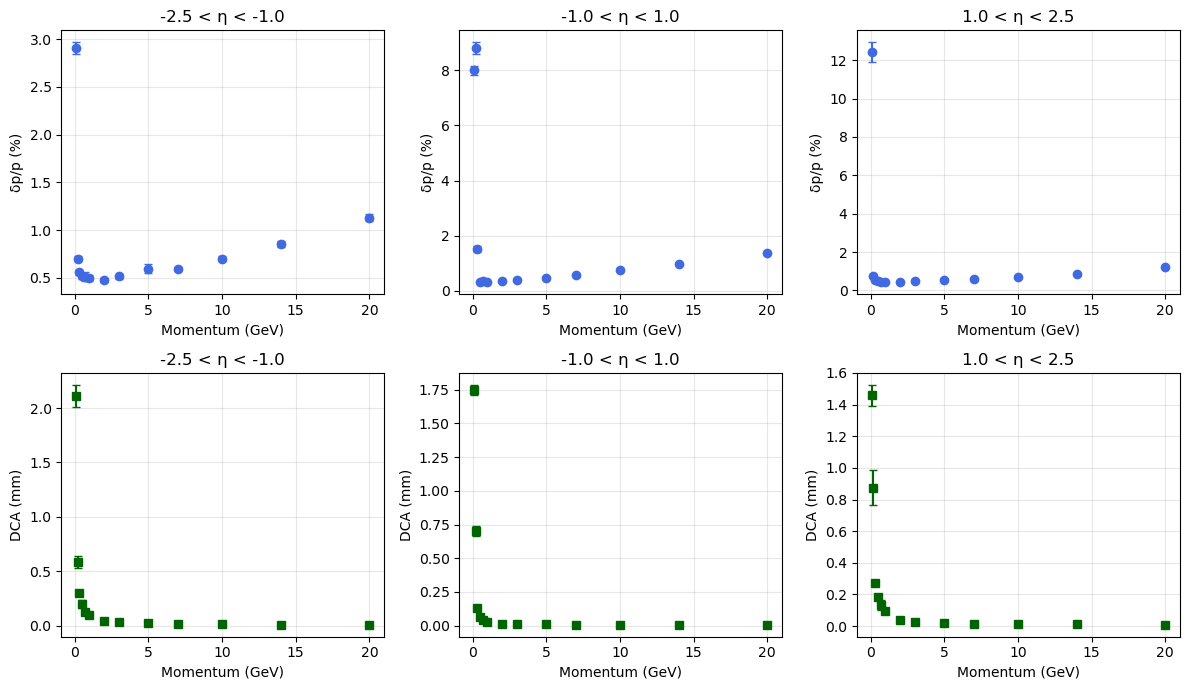

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(12, 7))

eta_bins = [
    (-2.5, -1.0),
    (-1.0,  1.0),
    ( 1.0,  2.5),
]

for i, (eta_lo, eta_hi) in enumerate(eta_bins):
    df_eta = df[(df["Pseudorapidity"] >= eta_lo) &
                (df["Pseudorapidity"] < eta_hi)]
    
    momentum_points = sorted(df_eta["Momentum (MeV/c)"].unique())

    p_Gev = []
    p_accuracy = []
    p_accuracy_err = []
    DCA = []
    DCA_err = []

    for p in momentum_points:
        subset = df_eta[df_eta["Momentum (MeV/c)"] == p]

        p_Gev.append(p / 1000.0) 
        p_accuracy.append(subset["Momentum Accuracy (%)"].mean())
        p_accuracy_err.append(subset["Momentum Accuracy (%)"].std() / np.sqrt(len(subset)))
        DCA.append(subset["DCA (mm)"].mean())
        DCA_err.append(subset["DCA (mm)"].std() / np.sqrt(len(subset)))
    
    ax = axes[0, i]
    ax.errorbar(p_Gev, p_accuracy, yerr=p_accuracy_err, fmt='o', color='royalblue', capsize=3)
    ax.set_title(f"{eta_lo} < η < {eta_hi}")
    ax.set_xlabel("Momentum (GeV)")
    ax.set_ylabel("δp/p (%)")
    ax.grid(alpha=0.3)

    ax = axes[1, i]
    ax.errorbar(p_Gev, DCA, yerr=DCA_err, fmt='s', color='darkgreen', capsize=3)
    ax.set_title(f"{eta_lo} < η < {eta_hi}")
    ax.set_xlabel("Momentum (GeV)")
    ax.set_ylabel("DCA (mm)")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

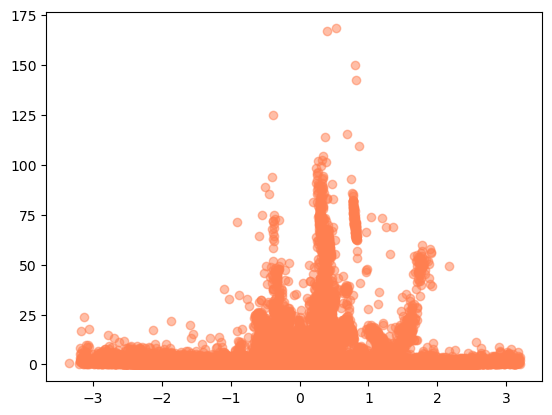

In [9]:
plt.scatter(df["Pseudorapidity"], df["Momentum Accuracy (%)"], alpha=0.5, color='coral')